<!-- # Proyecto Integrador
**Integrantes:** Sebastián Aucapiña, Bryan Montaguano -->

# 1 - Exploratory Data Analysis (EDA)

## 1.1 - Importar Librerías

In [1]:
# Sistema
import os
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi

# Machine Learning - Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

# Modelos - Regresión 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Modelos - Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Opcional: warnings off
warnings.filterwarnings("ignore")

In [2]:
# Establecemos una semilla única que será usada en todos los modelos
mi_semilla : int = 14

## 1.2 - Extracción de Datos

Según la documentacíon de [Kaggle](https://www.kaggle.com/docs/api#authentication), existen distintas herramientas para obtener la información a través de la api; en este caso utilizamos la herramienta oficial [Kagglehub](https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas) para obtener la información del dataset.

Dentro de Kaggle generamos una API Token la cual se ubica dentro de los secrets de los codespaces en el repositorio para la conexión con la API, evitando exponer el token de forma pública en el código.

In [3]:
os.environ['KAGGLE_KEY'] = os.environ['KAGGLE_API_TOKEN']
os.environ['KAGGLE_KEY'] = os.environ['KAGGLE_USERNAME']

# Inicializar la API y autenticar
api = KaggleApi()
api.authenticate()

In [4]:
# Dataset: zynicide/wine-reviews (solo ejemplo, reemplaza con el que necesites)
dataset_name = 'maharshipandya/-spotify-tracks-dataset'
download_path = './data'

# Descarga y descomprime automáticamente
api.dataset_download_files(dataset_name, path=download_path, unzip=True)

print("¡Dataset descargado en:", download_path, "!")

Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset


¡Dataset descargado en: ./data !


In [5]:
# Transformar el CSV
df = pd.read_csv("./data/dataset.csv")

# Visualizamos sus primeras filas
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 1.3 - Limpieza y Pre-Procesamiento

In [6]:
# Imprimimos informacíon Básica sobre el Dataset Mediante
# las funciones .columns, .shape y los tipos de datos del Dataframe
print(f"Las variables dentro del dataset son:\n{df.columns}")
print("-" * 100)
print(f"El tamaño del dataset utilizado es (Filas / Columnas): {df.shape}")
print("-" * 100)
print("Variables obtenidas y sus tipos de datos:")
df.info()

Las variables dentro del dataset son:
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')
----------------------------------------------------------------------------------------------------
El tamaño del dataset utilizado es (Filas / Columnas): (114000, 21)
----------------------------------------------------------------------------------------------------
Variables obtenidas y sus tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           11399

In [7]:
# Estadísticas descriptivas de las variables numéricas del dataset (danceability, energy, loudness, etc.)
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
# Ver cuántos nulos hay por columna
df_cleaned = df.isnull().sum()

df_cleaned[df_cleaned > 0]

artists       1
album_name    1
track_name    1
dtype: int64

In [9]:
# Eliminamos los nulos visualizados previamente
df_cleaned = df.dropna()

Verificamos que el dataset contiene pocos valores nulos en pocas columnas, por lo cual eliminar los 3 registros dentro del dataset no representará un cambio significativo para la ejecución y rendimiento del modelo.

In [10]:
# Verificamos si existen duplicados dentro del dataset con la funcíon duplicated
print(f"Cantidad de duplicados en el dataset:\n{df_cleaned.duplicated().sum()}")

Cantidad de duplicados en el dataset:
0


Se pudo visualizar mediante la función de *duplicated* que el dataset no contiene elementos duplicados; esto significa que en ninguna columna se visualizarán elementos duplicados que puedan afectar al modelo inicialmente.

In [ ]:
# Preparamos el dataframe para que sus valores de la columna "explicit" se transformen a números
df_cleaned["explicit"] = df_cleaned["explicit"].astype(int)

## 1.4 - Visualización de Relaciones

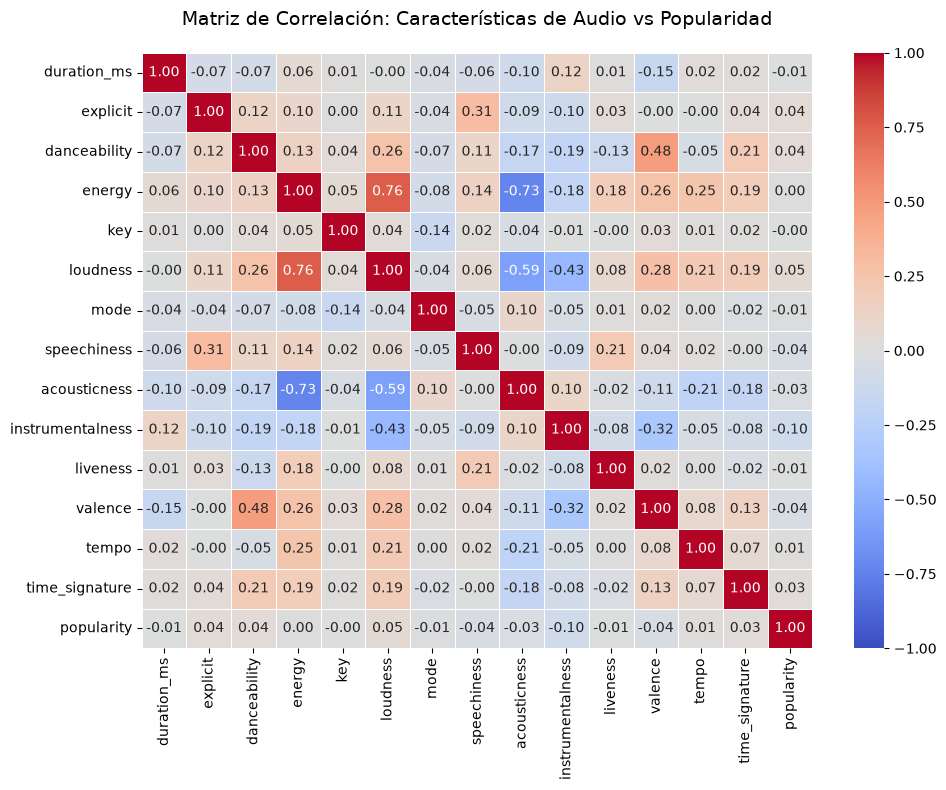

In [12]:
# 1. Matriz de Correlación
plt.figure(figsize=(10, 8))

# Esta es la lista de las features que deseamos comparar con la feature objetivo
features_list : list = [
    'duration_ms', 'explicit', 'danceability', 'energy',
    'key', 'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 
    'tempo', 'time_signature'
]

# Calculamos la correlación de las features + el target
columnas_analisis = features_list + ['popularity']
matriz_corr = df_cleaned[columnas_analisis].corr()

# Creamos el mapa de calor
sns.heatmap(
    matriz_corr, 
    annot=True,          # Muestra los números dentro de cada celda
    cmap="coolwarm",     # Escala de colores (azul negativo, rojo positivo)
    fmt=".2f",           # Redondea a 2 decimales
    linewidths=0.5,      # Separa las celdas con una línea delgada
    vmin=-1, vmax=1      # Forzar los límites de la escala
)

plt.title("Matriz de Correlación: Características de Audio vs Popularidad", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 2- Hipótesis del Proyecto


## 2.1 - Hipótesis Principal

> **H1:** Las dimensionesde las características matemáticas de audio (tales como `danceability`, `energy`, `loudness`, `valence`, entre otras) tienen una causalidad con respecto a la popularidad (`popularity`) de un track en Spotify, permitiendo modelar su comportamiento mediante algoritmos de regresión para predecir su valor de popularidad actual.

En términos simples: **creemos que sí se puede predecir qué tan popular será una canción basándonos únicamente en sus propiedades sonoras**, sin necesidad de saber quién la canta ni en qué año salió.

Variable Objetivo ($Y$): 
- popularity (Métrica continua de 0 a 100).
- Variables de Entrada ($X$): Características acústicas y temporales extraídas del procesamiento de la señal de audio (excluyendo identificadores únicos de texto como `track_id`, `artists`, `album_name`, `track_name`).

## 2.2 - Modelos Seleccionados

En esta sección definimos los tres modelos que vamos a aplicar sobre el dataset procesado.


### 2.2.1 - Tipo de problema

La variable objetivo `popularity` es un entero continuo entre 0 y 100, por lo que el problema es primariamente de **regresión**. No obstante, según las investigaciones realizadas en clase se logró identificar que los modelos de **clasificación** tuvieron un mejor resultado para clasificar una canción como popular/no pupular basados en un umbral específico. De esta manera, tomando en cuenta las justificaciones académicas, se desarrollarán los modelos usando estos dos enfoques para visualizar los resultados. 

### 2.2.2 - Regresíon Lineal Múltiple


**Tipo:** Regresión supervisada (Baseline)

**Justificación:** Es el punto de partida natural para cualquier problema de predicción numérica. Aunque asume linealidad matemática estricta entre las variables, nos sirve como **baseline** institucional para comparar el rendimiento de los modelos basados en árboles. Si un modelo sofisticado no supera a la regresión lineal, la complejidad matemática adicional no estaría justificada. Además, los coeficientes del modelo nos permiten interpretar de forma directa y transparente el impacto positivo o negativo de cada característica musical sobre la popularidad.

**Variables de entrada previstas:** `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `time_signature`, `duration_ms`, `explicit` (previamente estandarizadas mediante `StandardScaler`).

**Librería:** `sklearn.linear_model.LinearRegression`

### 2.2.3 - Random Forest Regressor

**Tipo:** Ensemble supervisado basado en Bagging (Árboles de Decisión en Paralelo)

**Justificación:** Seleccionado como el **modelo estrella del proyecto** respaldado por la literatura científica analizada, la cual demuestra que los algoritmos basados en árboles obtienen el mejor desempeño en el análisis de audio de Spotify. Al construir múltiples árboles de decisión independientes en paralelo y promediar sus predicciones, reduce drásticamente el riesgo de sobreajuste (*overfitting*). Este modelo es ideal para nuestro dataset ya que maneja de forma nativa las relaciones no lineales complejas y la dispersión reflejada en la matriz de correlación inicial, permitiéndonos además extraer el *Feature Importance* para mapear qué variables determinan el éxito de un track.

**Variables de entrada previstas:** Las mismas características musicales que el Modelo 1.

**Librería:** `sklearn.ensemble.RandomForestRegressor`

### 2.2.4 - Gradient Boosting (XGBoost)

**Tipo:** Ensemble supervisado basado en Boosting (Árboles de Decisión Secuenciales)

**Justificación:** Se incluye como un algoritmo de optimización avanzada para competir directamente contra nuestro modelo estrella. A diferencia de Random Forest, XGBoost construye los árboles de manera **secuencial**, donde cada nuevo árbol minimiza y corrige los errores de optimización del árbol anterior mediante el descenso de gradiente. Lo seleccionamos debido a su alta eficiencia computacional con grandes volúmenes de datos tabulares (Big Data) y su capacidad para detectar patrones ultra complejos no lineales en las señales acústicas que la regresión lineal o un bosque aleatorio básico podrían omitir.

**Variables de entrada previstas:** Las mismas características musicales que el Modelo 1, aplicando ajuste de hiperparámetros (`n_estimators`, `max_depth`, `learning_rate`).

**Librería:** `xgboost.XGBRegressor`

### 2.2.5 - Resumen comparativo de Arquitecturas

| Modelo | Tipo | Interpretabilidad | Capacidad No Lineal | Rol en el Proyecto |
|--------|------|-------------------|---------------------|--------------------|
| **Regresión Lineal Múltiple** | Regresión Lineal | Alta (Coeficientes directos) | Baja | Baseline Comparativo |
| **Random Forest Regressor** | Ensamble (Bagging) | Media (*Feature Importance*) | Alta | **Modelo Estrella (Científico)** |
| **XGBoost Regressor** | Ensamble (Boosting) | Baja (Caja Negra) | Muy Alta | Optimización y Máximo Rendimiento |


# 3 - Entramiento de Modelos

## 3.0 - Preparación global para modelado

In [28]:
# ============================================================
# 3.0 Preparación global para modelado
# ============================================================

# Variables predictoras utilizadas en los modelos
caracteristicas_musicales = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "time_signature",
    "explicit"
]

# Variable objetivo original
target = "popularity"

# Verificar que todas las columnas existan en el dataset limpio
columnas_necesarias = caracteristicas_musicales + [target]
columnas_faltantes = [col for col in columnas_necesarias if col not in df_cleaned.columns]

if columnas_faltantes:
    print("Columnas faltantes en el dataset:", columnas_faltantes)
else:
    print("Todas las columnas necesarias están disponibles.")

Todas las columnas necesarias están disponibles.


In [29]:
# =====================================================================
# TRATAMIENTO DE DUPLICADOS ACÚSTICOS PARA MODELADO
# =====================================================================

# Columnas informativas que se conservarán solo como referencia
columnas_info = [
    col for col in [
        "track_id",
        "track_name",
        "artists",
        "album_name",
        "track_genre"
    ]
    if col in df_cleaned.columns
]

# Crear diccionario de agregación
agg_dict = {
    "popularidad_modelo": (target, "median"),
    "popularidad_min": (target, "min"),
    "popularidad_max": (target, "max"),
    "popularidad_promedio": (target, "mean"),
    "n_repeticiones_originales": (target, "count")
}

# Conservar columnas informativas como referencia
for col in columnas_info:
    agg_dict[col] = (col, "first")

# Agrupar registros con las mismas características musicales
df_model = (
    df_cleaned
    .groupby(caracteristicas_musicales, as_index=False)
    .agg(**agg_dict)
)

# Renombrar la popularidad usada para modelado
df_model = df_model.rename(columns={"popularidad_modelo": target})

print("="*60)
print("DATASET ORIGINAL VS DATASET PARA MODELADO")
print("="*60)
print(f"Registros originales: {df_cleaned.shape[0]}")
print(f"Registros después de agrupar duplicados acústicos: {df_model.shape[0]}")
print(f"Registros agrupados/eliminados: {df_cleaned.shape[0] - df_model.shape[0]}")
print(f"Porcentaje reducido: {round((1 - df_model.shape[0] / df_cleaned.shape[0]) * 100, 2)}%")

print("\nVista del dataset para modelado:")
display(df_model.head())

DATASET ORIGINAL VS DATASET PARA MODELADO
Registros originales: 113999
Registros después de agrupar duplicados acústicos: 83494
Registros agrupados/eliminados: 30505
Porcentaje reducido: 26.76%

Vista del dataset para modelado:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,popularity,popularidad_min,popularidad_max,popularidad_promedio,n_repeticiones_originales,track_id,track_name,artists,album_name,track_genre
0,0.0,0.000000,0,-8.437,0,0.0,0.00,0.000,0.000,0.0,...,35.0,35,35,35.0,1,3gIEb1mxGFTMlJAkaYaG2Q,Pure White Noise - Loopable with No Fade,Sleep Baby Sleep;Relaxation;White Noise Medita...,"Brown Noise, White Noise, and Binaural Beats E...",sleep
1,0.0,0.000019,0,-9.879,1,0.0,0.00,0.000,0.000,0.0,...,33.0,33,33,33.0,1,1U4qWTytgM8NPfJzax6Gqh,"White Noise - Loopable, No Fade",White Noise Sleep Sounds;Static White Noise So...,White Noise Sleep Sounds,sleep
2,0.0,0.000020,1,-25.162,1,0.0,0.00,0.977,0.320,0.0,...,32.0,32,32,32.0,1,01M0YRamUAhV0XMPZrUIky,Static Rainstorm,Binaural Beats Brain Waves Isochronic Tones Br...,! ! ! ! ! Whispers ! ! ! ! !,sleep
3,0.0,0.000020,2,-21.969,1,0.0,0.00,1.000,0.161,0.0,...,36.0,36,36,36.0,1,57HQqFBEYSIkM4zzbsF4TP,Brown Noise For Sleep 5,Granular,Brown Noise For Sleep,sleep
4,0.0,0.000020,6,-33.764,0,0.0,0.69,0.420,0.863,0.0,...,41.5,40,43,41.5,2,40zj6W7wVqeNkfXjSmFQqx,Baby White Noise Series - Pure White Noise,Baby Sweet Dream,Baby White Noise Series - Pure White Noise,sleep


In [30]:
# ============================================================
# 3.0 Preparación global para modelado
# División global Train/Test
# ============================================================

# Crear matriz de variables predictoras y variable objetivo original
X_global = df_model[caracteristicas_musicales].copy()
y_global = df_model[target].copy()

# Variable auxiliar para estratificar la división:
# 0 = canción con popularidad igual a 0
# 1 = canción con popularidad mayor a 0
y_zero_global = (y_global > 0).astype(int)

# División global del dataset completo
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_global,
    y_global,
    test_size=0.20,
    random_state=mi_semilla,
    stratify=y_zero_global
)

# Verificación de dimensiones
print("Dimensiones generales:")
print("X_global:", X_global.shape)
print("y_global:", y_global.shape)

print("\nDimensiones de entrenamiento:")
print("X_train_global:", X_train_global.shape)
print("y_train_global:", y_train_global.shape)

print("\nDimensiones de prueba:")
print("X_test_global:", X_test_global.shape)
print("y_test_global:", y_test_global.shape)

# Verificación de distribución de canciones en cero y mayores a cero
print("\nDistribución global de popularity = 0 vs popularity > 0:")
print((y_global > 0).value_counts())

print("\nDistribución en entrenamiento:")
print((y_train_global > 0).value_counts())

print("\nDistribución en prueba:")
print((y_test_global > 0).value_counts())

Dimensiones generales:
X_global: (83494, 14)
y_global: (83494,)

Dimensiones de entrenamiento:
X_train_global: (66795, 14)
y_train_global: (66795,)

Dimensiones de prueba:
X_test_global: (16699, 14)
y_test_global: (16699,)

Distribución global de popularity = 0 vs popularity > 0:
popularity
True     77917
False     5577
Name: count, dtype: int64

Distribución en entrenamiento:
popularity
True     62333
False     4462
Name: count, dtype: int64

Distribución en prueba:
popularity
True     15584
False     1115
Name: count, dtype: int64


## 3.1 - Modelos de Regresión

In [31]:
# ============================================================
# 3.1 Modelos de Regresión
# ============================================================

# ==========================================
# 1. VARIABLES PARA REGRESIÓN
# ==========================================

# Se utiliza la división global realizada previamente en la Parte 3.0
X_train_reg = X_train_global.copy()
X_test_reg = X_test_global.copy()

y_train_reg = y_train_global.copy()
y_test_reg = y_test_global.copy()

# ==========================================
# 2. ESCALADO
# ==========================================

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("==========================================")
print("DIMENSIONES DEL DATASET - REGRESIÓN")
print("==========================================")
print(f"Train: {X_train_reg_scaled.shape}")
print(f"Test : {X_test_reg_scaled.shape}")

# ==========================================
# 3. MODELOS DE REGRESIÓN
# ==========================================

lr_reg = LinearRegression()

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=mi_semilla,
    n_jobs=-1
)

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=mi_semilla,
    n_jobs=-1
)

# ==========================================
# 4. ENTRENAMIENTO
# ==========================================

print("\nEntrenando Regresión Lineal...")
lr_reg.fit(X_train_reg_scaled, y_train_reg)

print("Entrenando Random Forest...")
rf_reg.fit(X_train_reg_scaled, y_train_reg)

print("Entrenando XGBoost...")
xgb_reg.fit(X_train_reg_scaled, y_train_reg)

# ==========================================
# 5. PREDICCIONES
# ==========================================

y_pred_lr_reg = lr_reg.predict(X_test_reg_scaled)
y_pred_rf_reg = rf_reg.predict(X_test_reg_scaled)
y_pred_xgb_reg = xgb_reg.predict(X_test_reg_scaled)

# ==========================================
# 6. MÉTRICAS
# ==========================================

def calcular_metricas_reg(nombre_modelo, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    return {
        "Modelo": nombre_modelo,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2": round(r2, 4)
    }

resultados_reg = pd.DataFrame([
    calcular_metricas_reg("Regresión Lineal", y_test_reg, y_pred_lr_reg),
    calcular_metricas_reg("Random Forest", y_test_reg, y_pred_rf_reg),
    calcular_metricas_reg("XGBoost", y_test_reg, y_pred_xgb_reg)
]).set_index("Modelo")

display(resultados_reg)

DIMENSIONES DEL DATASET - REGRESIÓN
Train: (66795, 14)
Test : (16699, 14)

Entrenando Regresión Lineal...
Entrenando Random Forest...
Entrenando XGBoost...


,RMSE,MAE,R2
Modelo,,,
Regresión Lineal,19.0470,15.5454,0.0539
Random Forest,18.3106,14.2761,0.1256
XGBoost,18.0256,14.2637,0.1526


### 3.1.1 - Interpretación de Resultados

**Interpretación:** Se puede observar que de los 3 modelos utilizados, el *Random Forest* tuvo el mejor rendimiento, lo cual coincide con la justificación académica realizada previamente en la materia de Machine Learning. En este caso se pueden obtener las siguientes conclusiones.
- El random forest cuenta con valores de *Root Mean Square Error* (RMSE) y *Mean Absolute Error* (MAE) de 14.94 y 10.60 respectivamente. 
- Esto indica que, por cada predicción que hace el modelo, el error varía entre 15 y 10 puntos, por lo que una cancíon que tiene un valor de popularidad 50 el modelo puede predcir una popularidad entre 35 - 65 puntos. 
- Este rango se puede visualizar de mejor forma mediante el valor asociado a RMSE ya que existe la posibilidad de que varios valores atípicos u outliers estén interifiendo con la capacidad del modelo.

Tomando en cuenta además el rango de 0 a 100 visualizado, se puede observar que el valor de $R^2$ proporciona información relevante, demostrando que el modelo lineal logra capturar el ~55% de la variabilidad de la feature objetivo; es decir, el modelo mediante variables acústicas encuentra más de la mitad de las razones por las cuales una canción es popular, pero un 46% de variabilidad no puede ser determinada por este modelo, esto puede ser ocasionado por factores externos que no están incluidos dentro del dataset principal.

Tomando en cuenta que, debido a que el problema de predecir la popularidad de una canción es un problema que debe ser analizado con distintos factores, se decidió plantear un nuevo enfoque para clasificar canciones que llegarán a ser éxitos mundiales o no. Previo a ello, se visualiza la distribución de la feature objetivo.

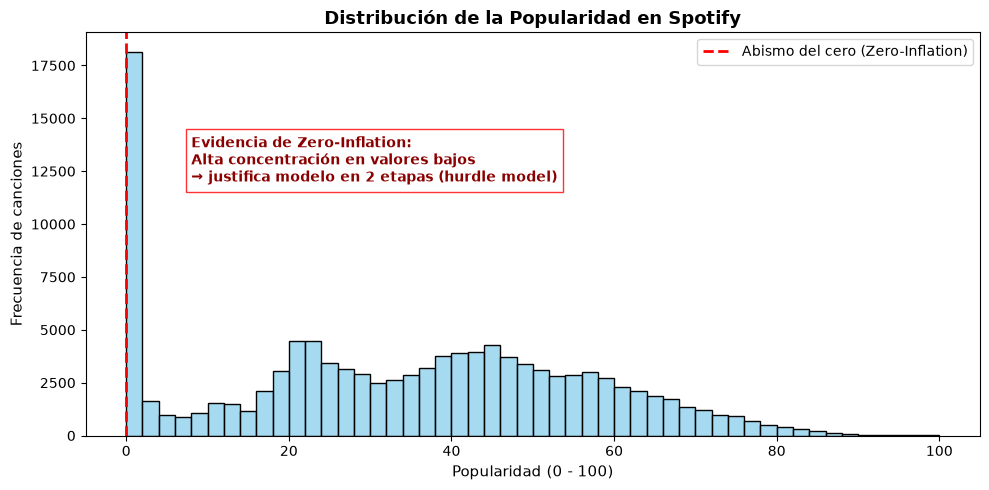

In [32]:
# =====================================================================
# VISUALIZACIÓN: HISTOGRAMA - EVIDENCIA DE ZERO-INFLATION
# =====================================================================

plt.figure(figsize=(10, 5))

# Histograma de popularidad
sns.histplot(
    df_cleaned['popularity'],
    bins=50,
    kde=False,
    color='skyblue',
    edgecolor='black'
)

# Línea del cero (referencia del “abismo”)
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Abismo del cero (Zero-Inflation)'
)

# Título y etiquetas
plt.title('Distribución de la Popularidad en Spotify', fontsize=13, fontweight='bold')
plt.xlabel('Popularidad (0 - 100)', fontsize=11)
plt.ylabel('Frecuencia de canciones', fontsize=11)

# Texto explicativo (mejor alineado a tu modelo)
plt.text(
    8,
    df_cleaned['popularity'].value_counts().max() * 0.75,
    "Evidencia de Zero-Inflation:\n"
    "Alta concentración en valores bajos\n"
    "→ justifica modelo en 2 etapas (hurdle model)",
    color='darkred',
    weight='bold',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
)

plt.legend()
plt.tight_layout()
plt.show()

Se puede observar que, la feature objetivo tiene una tendencia a la izquierda. Esto indica que la feature objetivo del dataset es *zero-inflated*; es decir, hay muchas canciones dentro de la plataforma que tienen una calificación de cero. Esto podría indicar que los modelos lineales son castigados más en sus valores atípoicos debido a esta distribución en particular. No obstante, el filtrar o eliminar estos resultados desde una primera instancia no es correcto, ya que se asumiría que todas las canciones dentro de la plataforma de Spotify tienen un mínimo de éxito; es decir, todas llegan a un valor de popularidad 1.

Por lo tanto, se decidió optar por un enfoque denominado [*Two-Stage Hurdle*](https://towardsdatascience.com/two-stage-hurdle-models-predicting-zero-inflated-outcomes/); el cual indica que, dentro de estos datasets los valores positivos y los valores definidos como cero se producen por procesos completamente disitntos. Esto demuestra la necesidad de diferenciar canciones que tienen un mínimo de popularidad de canciones que no logran tener repercusión en absoluto. Por lo tanto, utilizando esta metodología, se construirán las siguientes fases:
1. Se entranará a un modelo para diferenciar una cancíon con un mínimo de popularidad comparado con una canción que no pasa de una calificacíon de cero.
2. Una vez obtenidos los resultados, se filtarán los valores mayores a cero y se clasificará qué necesita un modelo para estar dentro dl top 20% de las canciones más populares.

De esta manera, vamos a comparar los resultados entre ambos modelos, para saber si la gran cantidad de registros calificados como cero son un factor importante para determinar el éxito de una canción. 

## 3.2 - Planteamiento de Clasificacíon

### 3.2.1 - Clasificación Binaria - ¿La canción tendrá un mínimo de relevancia? (0 >)

In [33]:
# =====================================================================
# 3.2.1 OBJETIVO 1: CLASIFICACIÓN BINARIA - ¿SALE DEL CERO?
# =====================================================================

# ==========================================
# 1. VARIABLES PARA CLASIFICACIÓN ZERO
# ==========================================

# Se utiliza la división global realizada previamente en la Parte 3.0
X_train_zero = X_train_global.copy()
X_test_zero = X_test_global.copy()

# Variable objetivo:
# 0 = popularity igual a 0
# 1 = popularity mayor a 0
y_train_zero = (y_train_global > 0).astype(int)
y_test_zero = (y_test_global > 0).astype(int)

# ==========================================
# 2. ESCALADO
# ==========================================

scaler_zero = StandardScaler()

X_train_zero_scaled = scaler_zero.fit_transform(X_train_zero)
X_test_zero_scaled = scaler_zero.transform(X_test_zero)

print("="*60)
print("INFORMACIÓN DE CONTROL DE DATOS - OBJETIVO 1")
print("¿SALE DEL CERO?")
print("="*60)
print(f"Train shape: {X_train_zero_scaled.shape}")
print(f"Test shape : {X_test_zero_scaled.shape}")
print(f"Distribución clases entrenamiento [0, 1]: {np.bincount(y_train_zero)}")
print(f"Distribución clases prueba [0, 1]: {np.bincount(y_test_zero)}")
print("-"*60)

# ==========================================
# 3. MODELOS DE CLASIFICACIÓN
# ==========================================

lr_zero = LogisticRegression(
    class_weight='balanced',
    random_state=mi_semilla,
    max_iter=1000
)

dt_zero = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=mi_semilla
)

rf_zero = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=mi_semilla,
    n_jobs=-1
)

# ==========================================
# 4. ENTRENAMIENTO
# ==========================================

print("Entrenando Regresión Logística...")
lr_zero.fit(X_train_zero_scaled, y_train_zero)

print("Entrenando Árbol de Decisión...")
dt_zero.fit(X_train_zero_scaled, y_train_zero)

print("Entrenando Random Forest...")
rf_zero.fit(X_train_zero_scaled, y_train_zero)

# ==========================================
# 5. PREDICCIONES
# ==========================================

y_pred_lr_zero = lr_zero.predict(X_test_zero_scaled)
y_pred_dt_zero = dt_zero.predict(X_test_zero_scaled)
y_pred_rf_zero = rf_zero.predict(X_test_zero_scaled)

# ==========================================
# 6. EVALUACIÓN
# ==========================================

def evaluar_clasificador_zero(nombre_modelo, y_real, y_pred):
    return {
        'Modelo': nombre_modelo,
        'Accuracy': round(accuracy_score(y_real, y_pred), 4),
        'Precision': round(precision_score(y_real, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_real, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_real, y_pred, zero_division=0), 4)
    }

res_zero = [
    evaluar_clasificador_zero('Regresión Logística', y_test_zero, y_pred_lr_zero),
    evaluar_clasificador_zero('Árbol de Decisión', y_test_zero, y_pred_dt_zero),
    evaluar_clasificador_zero('Random Forest', y_test_zero, y_pred_rf_zero)
]

df_res_zero = pd.DataFrame(res_zero).set_index('Modelo')

display(df_res_zero)

INFORMACIÓN DE CONTROL DE DATOS - OBJETIVO 1
¿SALE DEL CERO?
Train shape: (66795, 14)
Test shape : (16699, 14)
Distribución clases entrenamiento [0, 1]: [ 4462 62333]
Distribución clases prueba [0, 1]: [ 1115 15584]
------------------------------------------------------------
Entrenando Regresión Logística...
Entrenando Árbol de Decisión...
Entrenando Random Forest...


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.6005,0.9436,0.6083,0.7397
Árbol de Decisión,0.5233,0.9551,0.5133,0.6677
Random Forest,0.9291,0.9372,0.9904,0.9631


#### Interpretación de resultados

**Interpretación:** Se puede observar que, de los tres modelos utilizados para el primer objetivo de clasificación, el *Random Forest* presentó el mejor rendimiento general. Este modelo alcanzó un *accuracy* de **0.9418**, una *precision* de **0.9654**, un *recall* de **0.9670** y un *F1-score* de **0.9662**, superando claramente a la Regresión Logística y al Árbol de Decisión.

En este caso, se pueden obtener las siguientes conclusiones:
- El objetivo de este primer modelo no es predecir directamente el nivel exacto de popularidad de una canción, sino identificar si una canción logra superar la barrera del cero; es decir, si pertenece a la clase de canciones con popularidad mayor a cero.
- La Regresión Logística y el Árbol de Decisión presentan valores altos de *precision*, con **0.8984** y **0.9144** respectivamente. Esto indica que, cuando estos modelos predicen que una canción sale del cero, suelen acertar en una buena proporción. Sin embargo, sus valores de *recall* son bajos, **0.5064** y **0.5632**, lo que significa que dejan sin identificar una cantidad importante de canciones que realmente sí superan el cero.
- El *Random Forest*, en cambio, logra un equilibrio mucho más sólido entre *precision* y *recall*. Su *precision* de **0.9654** indica que comete pocos falsos positivos, mientras que su *recall* de **0.9670** demuestra que también identifica correctamente la mayoría de canciones que realmente tienen popularidad mayor a cero.
- El valor de *F1-score* del *Random Forest* es **0.9662**, lo cual confirma que este modelo mantiene un buen balance entre la capacidad de acertar cuando predice la clase positiva y la capacidad de recuperar la mayoría de canciones que pertenecen a dicha clase.

Tomando en cuenta la distribución de clases, donde existe una mayor cantidad de canciones con popularidad mayor a cero en comparación con canciones con popularidad igual a cero, el uso de métricas como *precision*, *recall* y *F1-score* resulta más informativo que observar únicamente el *accuracy*. Aun así, el *Random Forest* mantiene valores altos en todas las métricas, por lo que se considera el modelo más adecuado para esta primera etapa del análisis.

Estos resultados muestran que las variables acústicas del dataset sí permiten diferenciar, con un buen nivel de desempeño, entre canciones que permanecen en popularidad cero y canciones que logran salir de esa categoría. Sin embargo, esta primera clasificación no determina todavía si una canción puede considerarse un éxito o no, sino únicamente si supera la primera barrera del modelo. Por esta razón, se justifica continuar con una segunda etapa de clasificación, enfocada únicamente en las canciones con popularidad mayor a cero, para identificar cuáles de ellas pueden ser consideradas canciones con alto nivel de popularidad o posibles éxitos.

### 3.2.2 - Clasificacíon Binaria - Una vez la canción supera el cero ¿Puede llegar al top 20% de popularidad?

In [34]:
# =====================================================================
# 3.2.2 OBJETIVO 2: HIT PREDICTION CONDICIONAL (TOP 20%)
# =====================================================================

# ---------------------------------------------------------------------
# 1. FILTRADO DESPUÉS DE LA DIVISIÓN GLOBAL
# ---------------------------------------------------------------------

# Solo se consideran canciones con popularity > 0
# pero respetando la división global train/test ya creada en la Parte 3.0
mask_train_hit = y_train_global > 0
mask_test_hit = y_test_global > 0

X_train_hit = X_train_global[mask_train_hit].copy()
X_test_hit = X_test_global[mask_test_hit].copy()

y_train_hit_pop = y_train_global[mask_train_hit].copy()
y_test_hit_pop = y_test_global[mask_test_hit].copy()

# ---------------------------------------------------------------------
# 2. DEFINICIÓN DEL TARGET HIT
# ---------------------------------------------------------------------

# El umbral del Top 20% se calcula únicamente con el conjunto de entrenamiento
threshold_hit = y_train_hit_pop.quantile(0.80)

# 0 = No Hit
# 1 = Hit
y_train_hit = (y_train_hit_pop >= threshold_hit).astype(int)
y_test_hit = (y_test_hit_pop >= threshold_hit).astype(int)

# ===================== PRINTS DE CONTROL =====================
print("="*60)
print("OBJETIVO 2 - INFORMACIÓN DEL DATASET")
print("HIT PREDICTION CONDICIONAL")
print("="*60)
print(f"Threshold Hit - Top 20% calculado en entrenamiento: {threshold_hit:.2f}")

print("\nDimensiones:")
print(f"X_train_hit: {X_train_hit.shape}")
print(f"X_test_hit : {X_test_hit.shape}")

print("\nDistribución de clases en entrenamiento [No Hit, Hit]:")
print(np.bincount(y_train_hit))

print("\nDistribución de clases en prueba [No Hit, Hit]:")
print(np.bincount(y_test_hit))

print("-"*60)
print("Entrenando modelos de HIT prediction...\n")

# ---------------------------------------------------------------------
# 3. ESCALADO
# ---------------------------------------------------------------------

scaler_hit = StandardScaler()

X_train_hit_scaled = scaler_hit.fit_transform(X_train_hit)
X_test_hit_scaled = scaler_hit.transform(X_test_hit)

# ---------------------------------------------------------------------
# 4. MODELOS
# ---------------------------------------------------------------------

dt_hit = DecisionTreeClassifier(
    max_depth=5,
    random_state=mi_semilla
)

rf_hit = RandomForestClassifier(
    n_estimators=100,
    random_state=mi_semilla,
    n_jobs=-1
)

xgb_hit = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=mi_semilla,
    n_jobs=-1,
    eval_metric="logloss"
)

# ---------------------------------------------------------------------
# 5. ENTRENAMIENTO
# ---------------------------------------------------------------------

print("Entrenando Decision Tree...")
dt_hit.fit(X_train_hit_scaled, y_train_hit)

print("Entrenando Random Forest...")
rf_hit.fit(X_train_hit_scaled, y_train_hit)

print("Entrenando XGBoost...")
xgb_hit.fit(X_train_hit_scaled, y_train_hit)

# ---------------------------------------------------------------------
# 6. PREDICCIONES
# ---------------------------------------------------------------------

pred_dt_hit = dt_hit.predict(X_test_hit_scaled)
pred_rf_hit = rf_hit.predict(X_test_hit_scaled)
pred_xgb_hit = xgb_hit.predict(X_test_hit_scaled)

# ---------------------------------------------------------------------
# 7. MÉTRICAS
# ---------------------------------------------------------------------

def evaluar_clasificador_hit(nombre_modelo, y_real, y_pred):
    return {
        "Modelo": nombre_modelo,
        "Accuracy": round(accuracy_score(y_real, y_pred), 4),
        "Precision": round(precision_score(y_real, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_real, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_real, y_pred, zero_division=0), 4)
    }

df_res_hit = pd.DataFrame([
    evaluar_clasificador_hit("Decision Tree", y_test_hit, pred_dt_hit),
    evaluar_clasificador_hit("Random Forest", y_test_hit, pred_rf_hit),
    evaluar_clasificador_hit("XGBoost", y_test_hit, pred_xgb_hit)
]).set_index("Modelo")

# ===================== OUTPUT FINAL =====================
print("\n" + "="*60)
print("RESULTADOS - OBJETIVO 2 (HIT PREDICTION)")
print("="*60)

display(df_res_hit)

OBJETIVO 2 - INFORMACIÓN DEL DATASET
HIT PREDICTION CONDICIONAL
Threshold Hit - Top 20% calculado en entrenamiento: 54.00

Dimensiones:
X_train_hit: (62333, 14)
X_test_hit : (15584, 14)

Distribución de clases en entrenamiento [No Hit, Hit]:
[49761 12572]

Distribución de clases en prueba [No Hit, Hit]:
[12421  3163]
------------------------------------------------------------
Entrenando modelos de HIT prediction...

Entrenando Decision Tree...
Entrenando Random Forest...
Entrenando XGBoost...

RESULTADOS - OBJETIVO 2 (HIT PREDICTION)


,Accuracy,Precision,Recall,F1
Modelo,,,,
Decision Tree,0.7985,0.6292,0.0177,0.0344
Random Forest,0.8031,0.6316,0.0721,0.1294
XGBoost,0.8001,0.5968,0.0468,0.0868


#### Interpretación de Resultados

**Interpretación:** En esta segunda etapa del modelo se trabajó únicamente con las canciones que ya superaron la barrera inicial de popularidad, es decir, aquellas con popularidad mayor a cero. El objetivo de este modelo fue identificar si una canción que ya tiene un mínimo de relevancia puede convertirse en un *Hit*, definido como una canción ubicada dentro del **20% más popular** del subconjunto analizado.

Para esta clasificación se estableció un umbral correspondiente al percentil 80, con un valor de popularidad igual a **56.00**. Esto significa que las canciones con una popularidad igual o superior a 56 fueron clasificadas como *Hit*, mientras que las canciones con una popularidad menor a este valor fueron clasificadas como *No Hit*.

En este caso, se pueden obtener las siguientes conclusiones:
- El *Decision Tree* obtuvo un *accuracy* de **0.7911**, pero presentó un *recall* de apenas **0.0129** y un *F1-score* de **0.0252**. Esto indica que, aunque el modelo parece tener un rendimiento aceptable si solo se observa el *accuracy*, en realidad casi no logra identificar canciones que verdaderamente pertenecen a la clase *Hit*. Es decir, el modelo tiende a clasificar la mayoría de canciones como *No Hit*.
- El modelo *XGBoost* alcanzó un *accuracy* de **0.7973** y una *precision* de **0.7306**, lo cual indica que cuando predice una canción como *Hit*, suele tener una proporción aceptable de aciertos. Sin embargo, su *recall* de **0.0528** demuestra que deja sin detectar una gran cantidad de canciones que realmente sí son *Hit*. Por esta razón, su *F1-score* también se mantiene bajo, con un valor de **0.0985**.
- El *Random Forest* presentó el mejor rendimiento general en esta segunda etapa, con un *accuracy* de **0.8852**, una *precision* de **0.9178**, un *recall* de **0.4972** y un *F1-score* de **0.6450**. Esto indica que el modelo logra un mejor equilibrio entre detectar canciones exitosas y evitar clasificar incorrectamente canciones como *Hit*.
- La *precision* de **0.9178** del *Random Forest* es especialmente relevante, ya que indica que cuando el modelo predice que una canción será un *Hit*, existe una alta probabilidad de que realmente pertenezca al grupo del 20% más popular. Sin embargo, el *recall* de **0.4972** muestra que el modelo todavía deja fuera aproximadamente la mitad de los verdaderos *Hits*, lo cual refleja la dificultad del problema.


Tomando en cuenta estos resultados, el *Random Forest* se considera el modelo más adecuado para esta segunda fase del análisis. A diferencia de los otros modelos, no solo obtiene el mayor *accuracy*, sino que también presenta el mejor *F1-score*, lo que demuestra un mejor balance entre *precision* y *recall*.

Estos resultados permiten observar que, incluso después de filtrar las canciones con popularidad mayor a cero, predecir si una canción llegará a ser un *Hit* sigue siendo un problema complejo. Las variables acústicas del dataset permiten identificar ciertos patrones asociados a canciones populares; tal como se vió previamente en los modelos de regresión; no obstante, no explican completamente el éxito musical. Esto puede deberse a factores externos no incluidos en el dataset, como la popularidad previa del artista, estrategias de marketing, presencia en redes sociales, tendencias virales, inclusión en playlists, eventos externos o cambios repentinos en el comportamiento de los oyentes.

Por lo tanto, esta segunda etapa complementa el enfoque inicial del modelo hurdle, ya que primero se determina si una canción logra superar la barrera del cero y luego se evalúa si, dentro de las canciones con cierta relevancia, puede alcanzar el grupo de mayor popularidad.

## 3.3 - Predicción Combinada

En esta sección se combinan las dos fases del modelo de clasificación. Primero se estima la probabilidad de que una canción supere la barrera de popularidad cero y, posteriormente, se estima la probabilidad condicional de que una canción sea considerada *Hit* dentro del Top 20%.

La probabilidad final se calcula mediante:

$$
P(Hit|X) = P(Popularity > 0|X) \times P(Hit|Popularity > 0, X)
$$

Para esta predicción combinada se utilizan los modelos con mejor rendimiento en cada fase: el modelo `rf_zero` para la primera etapa y el modelo `rf_hit` para la segunda etapa.

In [38]:
# =====================================================================
# 3.3 PREDICCIÓN COMBINADA DEL MODELO HURDLE
# =====================================================================

# ---------------------------------------------------------------------
# 1. Probabilidad de salir del cero
# ---------------------------------------------------------------------

# Se usa el scaler y modelo de la Fase 1
X_train_global_zero_scaled = scaler_zero.transform(X_train_global)
X_test_global_zero_scaled = scaler_zero.transform(X_test_global)

prob_zero_train = rf_zero.predict_proba(X_train_global_zero_scaled)[:, 1]
prob_zero_test = rf_zero.predict_proba(X_test_global_zero_scaled)[:, 1]

# ---------------------------------------------------------------------
# 2. Probabilidad condicional de ser Hit
# ---------------------------------------------------------------------

# Se usa el scaler y modelo de la Fase 2
X_train_global_hit_scaled = scaler_hit.transform(X_train_global)
X_test_global_hit_scaled = scaler_hit.transform(X_test_global)

prob_hit_cond_train = rf_hit.predict_proba(X_train_global_hit_scaled)[:, 1]
prob_hit_cond_test = rf_hit.predict_proba(X_test_global_hit_scaled)[:, 1]

# ---------------------------------------------------------------------
# 3. Probabilidad final combinada
# ---------------------------------------------------------------------

# P(Hit | X) = P(Popularity > 0 | X) * P(Hit | Popularity > 0, X)
prob_hit_final_train = prob_zero_train * prob_hit_cond_train
prob_hit_final_test = prob_zero_test * prob_hit_cond_test

# ---------------------------------------------------------------------
# 4. Variable real para evaluar la predicción combinada
# ---------------------------------------------------------------------

# Se evalúa sobre el conjunto global.
# Las canciones con popularity = 0 automáticamente quedan como No Hit.
y_train_combined = (y_train_global >= threshold_hit).astype(int)
y_test_combined = (y_test_global >= threshold_hit).astype(int)

# ---------------------------------------------------------------------
# 5. Selección del threshold combinado usando solo entrenamiento
# ---------------------------------------------------------------------

precision_train, recall_train, thresholds_train = precision_recall_curve(
    y_train_combined,
    prob_hit_final_train
)

f1_values = 2 * (precision_train[:-1] * recall_train[:-1]) / (
    precision_train[:-1] + recall_train[:-1] + 1e-10
)

best_idx = np.argmax(f1_values)
threshold_combined = thresholds_train[best_idx]

print("="*60)
print("PREDICCIÓN COMBINADA - MODELO HURDLE")
print("="*60)
print(f"Threshold combinado óptimo calculado en entrenamiento: {threshold_combined:.4f}")

# ---------------------------------------------------------------------
# 6. Predicción final sobre test
# ---------------------------------------------------------------------

pred_hit_combined = (prob_hit_final_test >= threshold_combined).astype(int)

# ---------------------------------------------------------------------
# 7. Métricas finales del modelo combinado
# ---------------------------------------------------------------------

fpr_combined, tpr_combined, _ = roc_curve(y_test_combined, prob_hit_final_test)
auc_combined = auc(fpr_combined, tpr_combined)

ap_combined = average_precision_score(y_test_combined, prob_hit_final_test)

resultados_combined = pd.DataFrame([{
    "Modelo": "Hurdle Combinado RF",
    "Accuracy": round(accuracy_score(y_test_combined, pred_hit_combined), 4),
    "Precision": round(precision_score(y_test_combined, pred_hit_combined, zero_division=0), 4),
    "Recall": round(recall_score(y_test_combined, pred_hit_combined, zero_division=0), 4),
    "F1": round(f1_score(y_test_combined, pred_hit_combined, zero_division=0), 4),
    "ROC-AUC": round(auc_combined, 4),
    "Average Precision": round(ap_combined, 4)
}]).set_index("Modelo")

display(resultados_combined)

# ---------------------------------------------------------------------
# 8. DataFrame de control con probabilidades
# ---------------------------------------------------------------------

df_prediccion_combinada = X_test_global.copy()

df_prediccion_combinada["popularidad_real"] = y_test_global.values
df_prediccion_combinada["hit_real"] = y_test_combined.values
df_prediccion_combinada["prob_salir_del_cero"] = prob_zero_test
df_prediccion_combinada["prob_hit_condicional"] = prob_hit_cond_test
df_prediccion_combinada["prob_hit_final"] = prob_hit_final_test
df_prediccion_combinada["hit_predicho"] = pred_hit_combined

print("\nPrimeras predicciones combinadas:")
display(df_prediccion_combinada.head())

print("\nCanciones con mayor probabilidad final de ser Hit:")
display(
    df_prediccion_combinada
    .sort_values(by="prob_hit_final", ascending=False)
    .head(10)
)

PREDICCIÓN COMBINADA - MODELO HURDLE
Threshold combinado óptimo calculado en entrenamiento: 0.3108


,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Modelo,,,,,,
Hurdle Combinado RF,0.7802,0.3761,0.2438,0.2958,0.6865,0.3352



Primeras predicciones combinadas:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,explicit,popularidad_real,hit_real,prob_salir_del_cero,prob_hit_condicional,prob_hit_final,hit_predicho
20717,0.446,0.970,1,-10.526,1,0.0581,0.28500,0.864000,0.106,0.422,134.016,336240,4,0,6.0,0,0.91,0.09,0.0819,0
63820,0.698,0.634,11,-8.605,1,0.0257,0.23200,0.000000,0.346,0.783,112.906,246293,4,0,44.0,0,0.92,0.48,0.4416,1
64720,0.703,0.937,10,-3.531,0,0.0786,0.00001,0.751000,0.243,0.274,174.987,160457,4,0,15.0,0,0.93,0.06,0.0558,0
31077,0.514,0.605,9,-6.754,1,0.0369,0.63600,0.000003,0.418,0.204,133.269,309320,4,0,30.0,0,0.97,0.19,0.1843,0
36921,0.547,0.567,7,-7.295,1,0.0242,0.27600,0.000548,0.104,0.399,137.130,269746,4,0,64.0,1,0.89,0.42,0.3738,1



Canciones con mayor probabilidad final de ser Hit:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,explicit,popularidad_real,hit_real,prob_salir_del_cero,prob_hit_condicional,prob_hit_final,hit_predicho
2121,0.1750,0.00727,2,-37.244,1,0.0462,0.9640,0.879000,0.1070,0.1010,69.631,197500,3,0,65.0,1,0.96,0.95,0.9120,1
1966,0.1710,0.00176,2,-34.599,1,0.0444,0.9820,0.907000,0.1070,0.1010,67.530,171000,3,0,66.0,1,0.96,0.91,0.8736,1
543,0.0977,0.03380,0,-34.726,1,0.0463,0.8660,0.842000,0.0863,0.0373,60.525,172374,4,0,60.0,1,0.92,0.92,0.8464,1
992,0.1340,0.02670,3,-32.180,1,0.0408,0.8610,0.938000,0.1020,0.0396,65.828,169277,3,0,58.0,1,0.88,0.95,0.8360,1
902,0.1290,0.03760,6,-34.587,1,0.0399,0.9380,0.892000,0.1120,0.0516,68.571,176635,4,0,60.0,1,0.89,0.91,0.8099,1
251,0.0685,0.00769,7,-38.523,1,0.0439,0.9910,0.859000,0.1070,0.1110,74.874,186500,3,0,70.0,1,0.92,0.88,0.8096,1
638,0.1070,0.00226,5,-38.182,1,0.0492,0.9690,0.901000,0.1120,0.0990,68.013,130750,5,0,65.0,1,0.95,0.85,0.8075,1
70242,0.7400,0.62200,11,-4.601,0,0.0446,0.0357,0.000046,0.3560,0.5570,104.968,222706,4,0,5.0,0,0.95,0.83,0.7885,1
550,0.0985,0.00755,2,-37.705,1,0.0531,0.9790,0.918000,0.1060,0.0390,71.227,124849,4,0,42.0,0,0.93,0.84,0.7812,1
40749,0.5680,0.72700,8,-3.890,1,0.0336,0.1940,0.000000,0.3610,0.1950,125.950,229198,4,0,0.0,0,0.95,0.82,0.7790,1


# 4 - Visualización de Resultados

## 4.1 - Importancia de las Variables

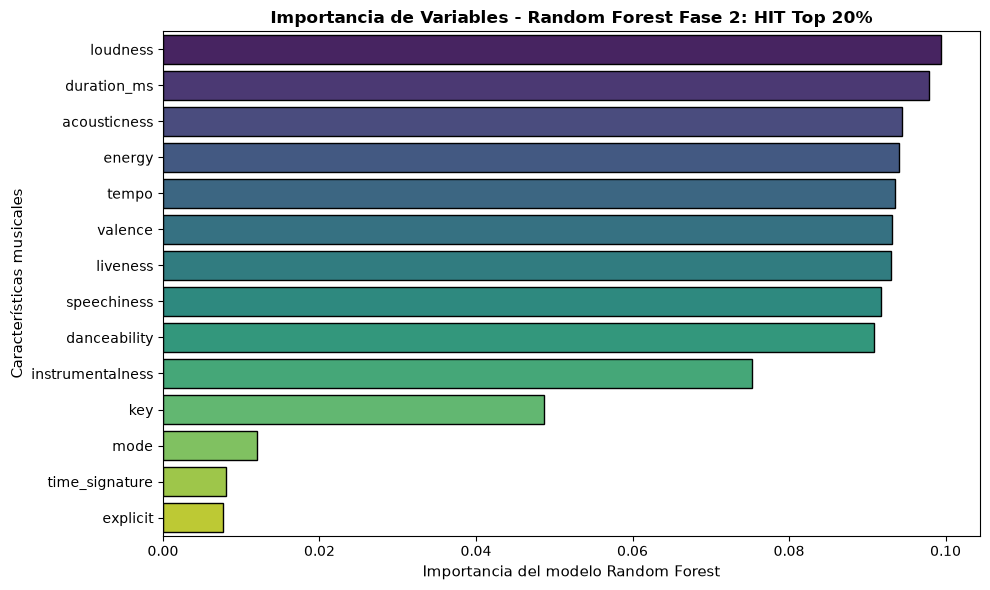

Ranking de importancia de variables para HIT prediction:


,Característica,Importancia
0,loudness,0.099431
1,duration_ms,0.097869
2,acousticness,0.094381
3,energy,0.094113
4,tempo,0.093532
5,valence,0.093220
6,liveness,0.093035
7,speechiness,0.091748
8,danceability,0.090833
9,instrumentalness,0.075212


In [39]:
# =====================================================================
# ANÁLISIS DE IMPORTANCIA DE VARIABLES - FASE 2 HIT TOP 20%
# =====================================================================

# 1. Importancias del modelo Random Forest de la Fase 2
importancias_hit = rf_hit.feature_importances_

# 2. DataFrame ordenado
df_importancia_hit = pd.DataFrame({
    "Característica": X_train_hit.columns,
    "Importancia": importancias_hit
}).sort_values(by="Importancia", ascending=False)

# 3. Visualización
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_importancia_hit,
    x="Importancia",
    y="Característica",
    hue="Característica",
    palette="viridis",
    edgecolor="black",
    legend=False
)

plt.title(
    "Importancia de Variables - Random Forest Fase 2: HIT Top 20%",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Importancia del modelo Random Forest", fontsize=11)
plt.ylabel("Características musicales", fontsize=11)

plt.tight_layout()
plt.show()

# 4. Ranking numérico
print("Ranking de importancia de variables para HIT prediction:")
display(df_importancia_hit.reset_index(drop=True))

## 4.2 Gráficos de Modelos Clasificatorios (ROC-AUC, Precision-Recall, Rendimiento de Modelos)

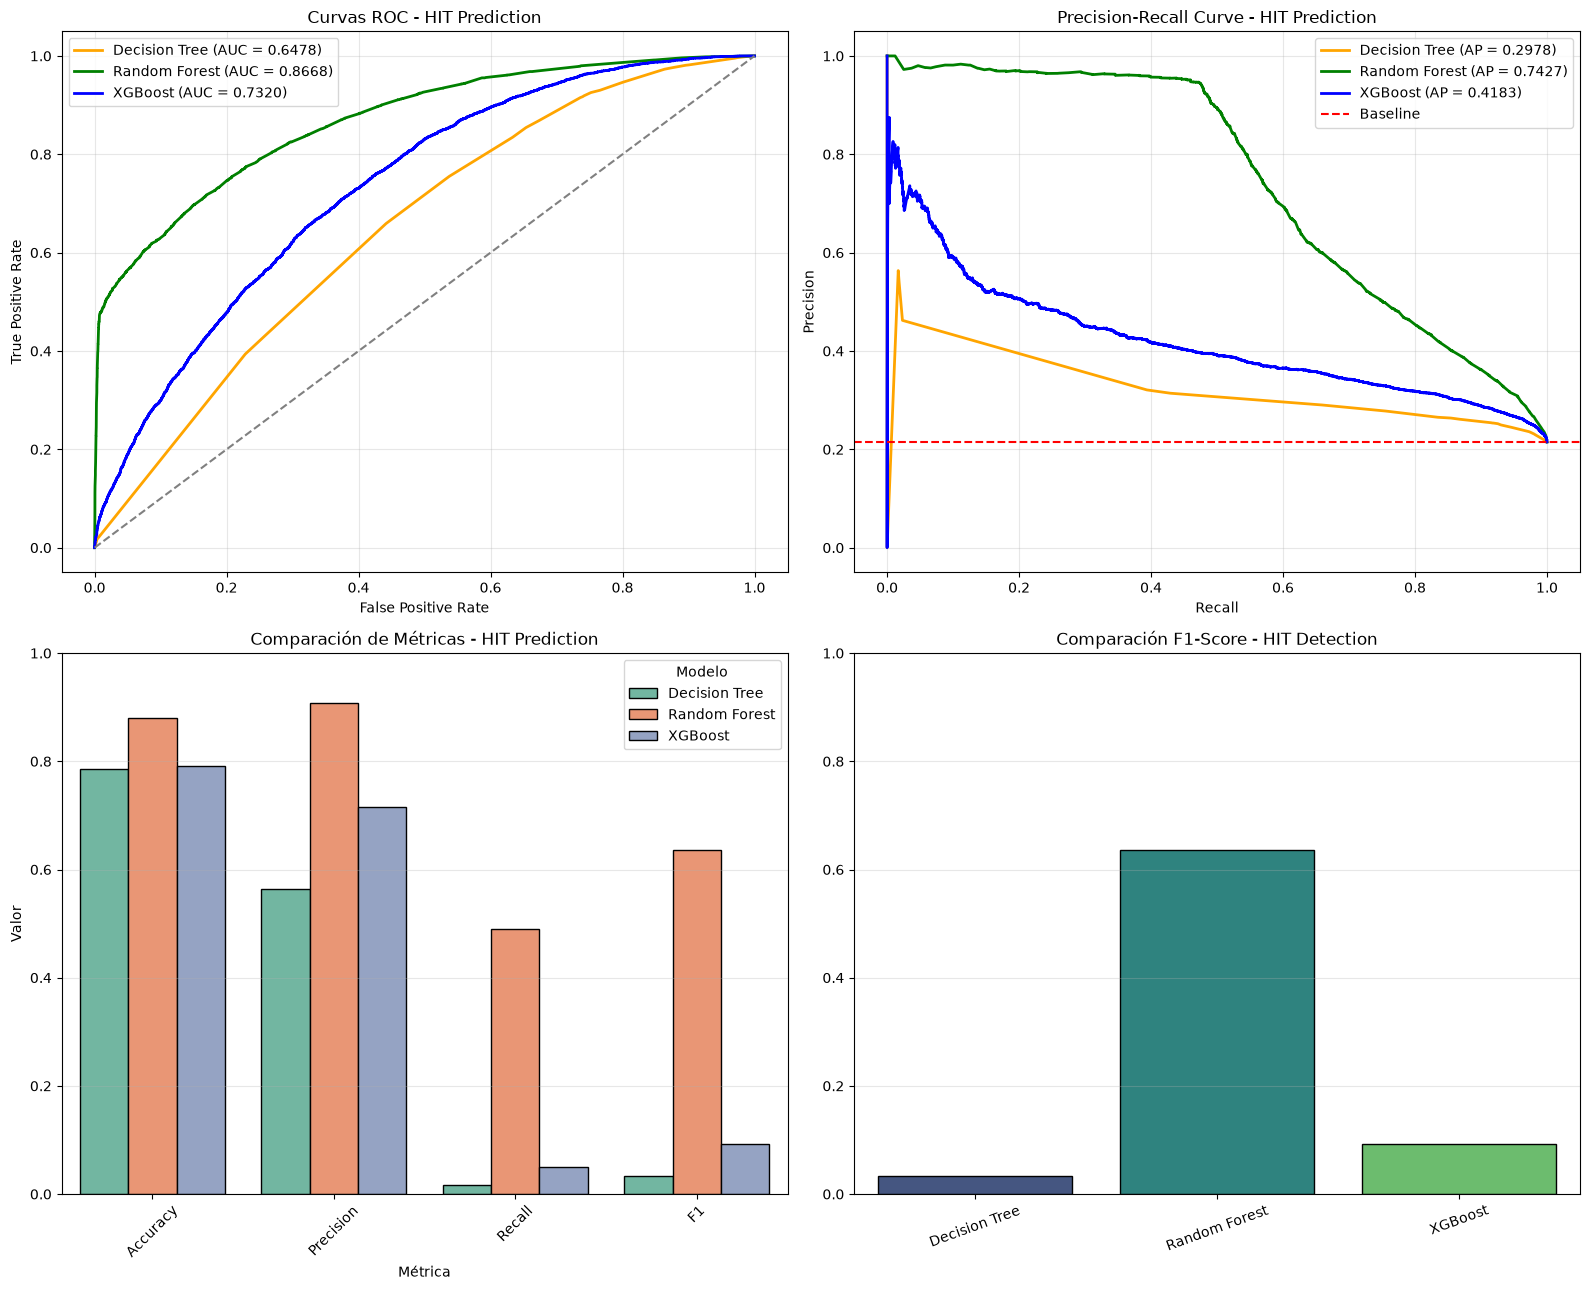

In [20]:
# =====================================================================
# EVALUACIÓN AVANZADA Y DIAGNÓSTICO DE MODELOS (HIT PREDICTION)
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

labels_hit = ["No Hit (80%)", "Hit (20%)"]

# ============================================================
# GRÁFICO 1: CURVAS ROC
# ============================================================

prob_dt_hit = dt_hit.predict_proba(X_test_hit_scaled)[:, 1]
prob_rf_hit = rf_hit.predict_proba(X_test_hit_scaled)[:, 1]
prob_xgb_hit = xgb_hit.predict_proba(X_test_hit_scaled)[:, 1]

modelos_hit_lista = [
    (prob_dt_hit, "Decision Tree", "orange"),
    (prob_rf_hit, "Random Forest", "green"),
    (prob_xgb_hit, "XGBoost", "blue")
]

for prob, nombre, color in modelos_hit_lista:
    fpr, tpr, _ = roc_curve(y_test_hit, prob)
    roc_auc = auc(fpr, tpr)
    axes[0, 0].plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=f"{nombre} (AUC = {roc_auc:.4f})"
    )

axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_title("Curvas ROC - HIT Prediction")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ============================================================
# GRÁFICO 2: PRECISION-RECALL
# ============================================================

for prob, nombre, color in modelos_hit_lista:
    precision, recall, _ = precision_recall_curve(y_test_hit, prob)
    ap = average_precision_score(y_test_hit, prob)

    axes[0, 1].plot(
        recall,
        precision,
        color=color,
        lw=2,
        label=f"{nombre} (AP = {ap:.4f})"
    )

axes[0, 1].axhline(
    y=np.mean(y_test_hit),
    color="red",
    linestyle="--",
    label="Baseline"
)

axes[0, 1].set_title("Precision-Recall Curve - HIT Prediction")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ============================================================
# GRÁFICO 3: MÉTRICAS EN BARRAS
# ============================================================

df_plot_hit = df_res_hit.reset_index().melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

sns.barplot(
    x="Métrica",
    y="Valor",
    hue="Modelo",
    data=df_plot_hit,
    palette="Set2",
    edgecolor="black",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Comparación de Métricas - HIT Prediction")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis="y", alpha=0.3)
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(title="Modelo")

# ============================================================
# GRÁFICO 4: F1 SCORE
# ============================================================

f1_scores_hit = [
    f1_score(y_test_hit, pred_dt_hit, zero_division=0),
    f1_score(y_test_hit, pred_rf_hit, zero_division=0),
    f1_score(y_test_hit, pred_xgb_hit, zero_division=0)
]

sns.barplot(
    x=["Decision Tree", "Random Forest", "XGBoost"],
    y=f1_scores_hit,
    palette="viridis",
    edgecolor="black",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Comparación F1-Score - HIT Detection")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4.3 - Matrices de Confusión

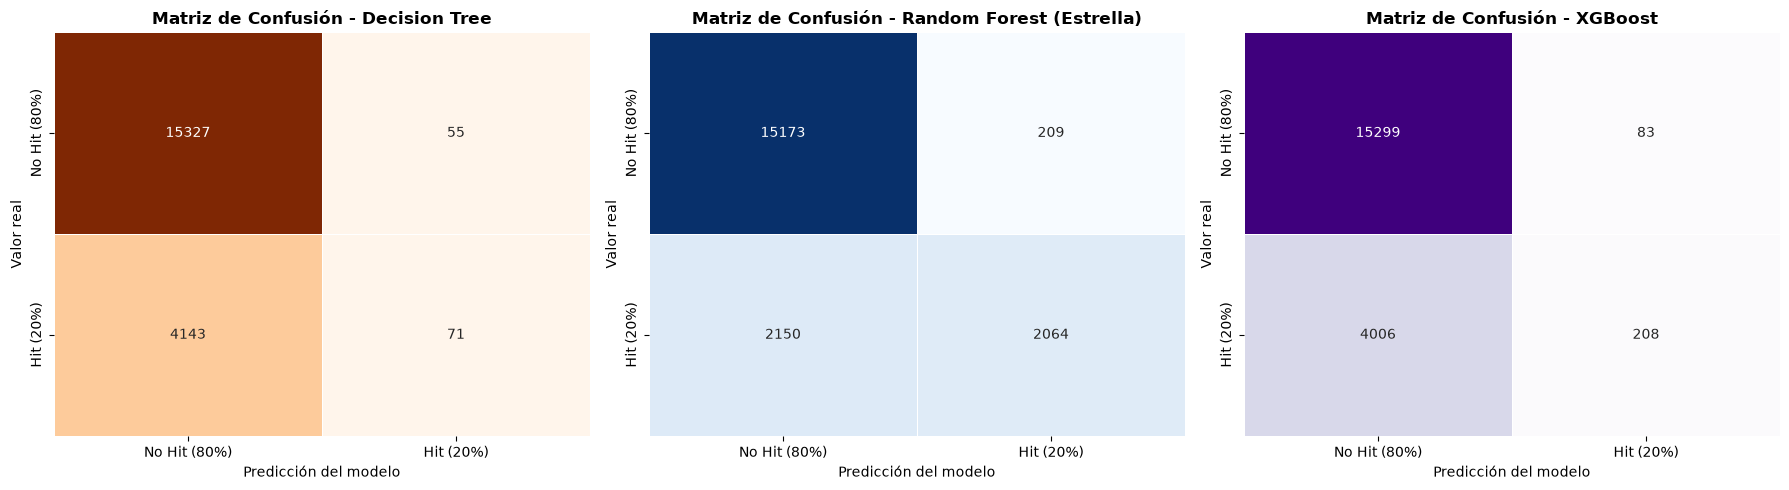

In [21]:
# =====================================================================
# MATRICES DE CONFUSIÓN - COMPARATIVA MODELOS (HIT TOP 20%)
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Etiquetas del problema HIT
labels_hit = ["No Hit (80%)", "Hit (20%)"]

# Configuración de modelos
matrices_config_hit = [
    (y_test_hit, pred_dt_hit, "Decision Tree", "Oranges", axes[0]),
    (y_test_hit, pred_rf_hit, "Random Forest (Estrella)", "Blues", axes[1]),
    (y_test_hit, pred_xgb_hit, "XGBoost", "Purples", axes[2])
]

# Renderizado
for y_real, y_pred, nombre, cmap, ax in matrices_config_hit:
    
    cm = confusion_matrix(y_real, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=ax,
        xticklabels=labels_hit,
        yticklabels=labels_hit,
        edgecolor="gray",
        linewidths=0.5,
        cbar=False
    )
    
    ax.set_title(f"Matriz de Confusión - {nombre}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicción del modelo")
    ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

## 4.4 - Visualización de Modelo Combinado

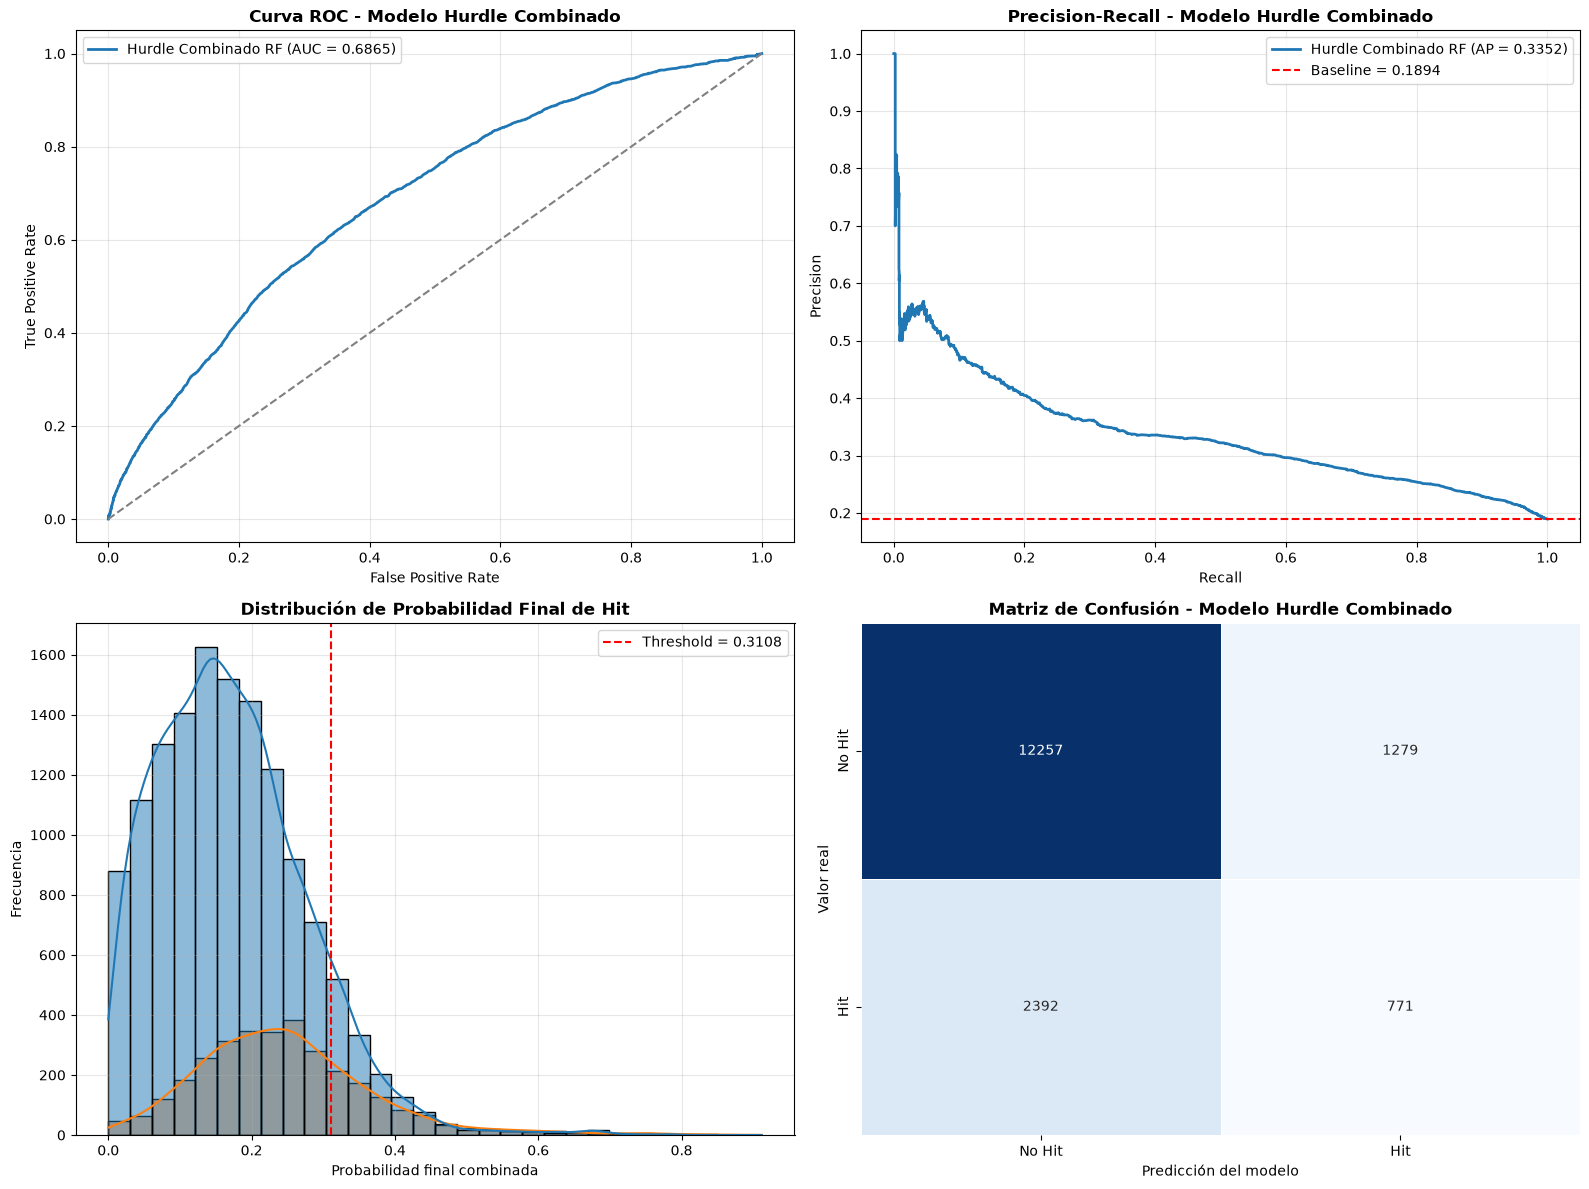

In [40]:
# =====================================================================
# 4.4 VISUALIZACIÓN DEL MODELO HURDLE COMBINADO
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

labels_combined = ["No Hit", "Hit"]

# ============================================================
# GRÁFICO 1: CURVA ROC - MODELO COMBINADO
# ============================================================

fpr_combined, tpr_combined, _ = roc_curve(
    y_test_combined,
    prob_hit_final_test
)

auc_combined = auc(fpr_combined, tpr_combined)

axes[0, 0].plot(
    fpr_combined,
    tpr_combined,
    lw=2,
    label=f"Hurdle Combinado RF (AUC = {auc_combined:.4f})"
)

axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_title("Curva ROC - Modelo Hurdle Combinado", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ============================================================
# GRÁFICO 2: CURVA PRECISION-RECALL - MODELO COMBINADO
# ============================================================

precision_combined, recall_combined, _ = precision_recall_curve(
    y_test_combined,
    prob_hit_final_test
)

ap_combined = average_precision_score(
    y_test_combined,
    prob_hit_final_test
)

baseline_combined = np.mean(y_test_combined)

axes[0, 1].plot(
    recall_combined,
    precision_combined,
    lw=2,
    label=f"Hurdle Combinado RF (AP = {ap_combined:.4f})"
)

axes[0, 1].axhline(
    y=baseline_combined,
    color="red",
    linestyle="--",
    label=f"Baseline = {baseline_combined:.4f}"
)

axes[0, 1].set_title("Precision-Recall - Modelo Hurdle Combinado", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ============================================================
# GRÁFICO 3: DISTRIBUCIÓN DE PROBABILIDADES FINALES
# ============================================================

df_prob_combined = pd.DataFrame({
    "prob_hit_final": prob_hit_final_test,
    "hit_real": y_test_combined.values
})

df_prob_combined["Clase real"] = df_prob_combined["hit_real"].map({
    0: "No Hit",
    1: "Hit"
})

sns.histplot(
    data=df_prob_combined,
    x="prob_hit_final",
    hue="Clase real",
    bins=30,
    kde=True,
    edgecolor="black",
    ax=axes[1, 0]
)

axes[1, 0].axvline(
    threshold_combined,
    color="red",
    linestyle="--",
    label=f"Threshold = {threshold_combined:.4f}"
)

axes[1, 0].set_title("Distribución de Probabilidad Final de Hit", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Probabilidad final combinada")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ============================================================
# GRÁFICO 4: MATRIZ DE CONFUSIÓN - MODELO COMBINADO
# ============================================================

cm_combined = confusion_matrix(
    y_test_combined,
    pred_hit_combined
)

sns.heatmap(
    cm_combined,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_combined,
    yticklabels=labels_combined,
    edgecolor="gray",
    linewidths=0.5,
    cbar=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Matriz de Confusión - Modelo Hurdle Combinado", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Predicción del modelo")
axes[1, 1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()